# Test the statistical method for different scenario

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
c0 ={'acc':'#941717', 'cor':'#388E3C','ggd':'#42A5F5', 'wd':'#FFA000', 'sum':'lightgrey'}
plt.rcParams["hatch.linewidth"] = 8
from diagnosis import compute_mean_square
from cstes import U

In [2]:
N=100000 # nb coloc

__________________________
# 1. No errors
## 1.1. Gradient wind balance

$$u_{\theta} = -\frac{1}{2}fr \pm \frac{1}{2}fr\sqrt{1+\frac{4}{fr}u_g} $$

$$\frac{u_{\theta}^2}{r} + fu_{\theta} = fu_g$$

$$u_g = \frac{fr}{4}[(\frac{2u_{\theta}}{fr}-1)^2-1]$$

In [5]:
def compute_u_theta(f, r, ug):
    a = -1/2*f*r 
    b = 1/2*f*r*np.sqrt(1+4*ug/f/r)
    return a-b, a+b
def compute_ug(f, r, utheta):
    return f*r/4*((2*utheta/f/r+1)**2-1)

$$ \frac{4u_g}{fr}>-1 $$

In [210]:
ds.differentiate?

Signature:
ds.differentiate(
    coord: 'Hashable',
    edge_order: 'Literal[1, 2]' = 1,
    datetime_unit: 'DatetimeUnitOptions | None' = None,
) -> 'Self'
Docstring:
Differentiate with the second order accurate central
differences.

.. note::
    This feature is limited to simple cartesian geometry, i.e. coord
    must be one dimensional.

Parameters
----------
coord : Hashable
    The coordinate to be used to compute the gradient.
edge_order : {1, 2}, default: 1
    N-th order accurate differences at the boundaries.
datetime_unit : None or {"Y", "M", "W", "D", "h", "m", "s", "ms",             "us", "ns", "ps", "fs", "as", None}, default: None
    Unit to compute gradient. Only valid for datetime coordinate.

Returns
-------
differentiated: Dataset

See also
--------
numpy.gradient: corresponding numpy function
File:      /opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/dataset.py
Type:      method

In [356]:
import numpy as np
# define normalized 2D gaussian
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

def create_champ(L = 30e3, std=30e3, lat=40, dsl_amp=-3e-2):
    g=9.81
    x = np.arange(-L, L, 1e3)
    y = np.arange(-L, L, 1e3)

    X, Y = np.meshgrid(x, y) # get 2D variables instead of 1D
    z = gaus2d(X, Y, mx=0, my=0, sx=10e3, sy=10e3)
    z = z/z.max()*dsl_amp


    ds = xr.Dataset(
        data_vars=dict(
            eta=(["y","x"], z),
        ), 
        coords=dict( y=("y", y), x=("x", x),
                   ))

    ds['eta'] = ds['eta'].assign_attrs({'long_name':r'DSL $\eta$', 'unit':'m'})
    ds['x'] = ds['x'].assign_attrs({'unit':'m'})
    ds['y'] = ds['y'].assign_attrs({'unit':'m'})

    f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
    ds['r'] = np.sqrt(ds.x**2+ds.y**2)
    ds['cos'] = (ds.x/ds.r)
    ds['sin'] = (ds.y/ds.r)

    ds['dxeta'] = ds['eta'].differentiate('x')
    ds['dyeta'] = ds['eta'].differentiate('y')
    ds['dreta'] = ds.dxeta*ds.cos + ds.dyeta*ds.sin

    ds['ugx'] = g/f*ds.dyeta
    ds['ugy'] = -g/f*ds.dxeta
    ds['ug'] = g/f*ds.dreta

    def compute_u_theta(f, r, ug):
        a = -1/2*f*r 
        b = 1/2*f*r*np.sqrt(1+4*ug/f/r)
        return a-b, a+b
    
    ds['utheta0'] = compute_u_theta(f, ds.r, ds.ug)[0]
    ds['utheta1'] = compute_u_theta(f, ds.r, ds.ug)[1]
    ds['utheta1x'] = -ds.utheta1*(ds.sin)
    ds['utheta1y'] = ds.utheta1*(ds.cos)
    ds = ds.transpose('y','x')

    ds['acc'] = ds.utheta1**2/ds.r
    ds['cor'] = f*ds.utheta1
    ds['ggd'] = -g*ds.dreta
    
    ds['accx'] = ds.acc*(ds.cos)
    ds['accy'] = ds.acc*(ds.sin)
    ds['corx'] = ds.cor*(ds.cos)
    ds['cory'] = ds.cor*(ds.sin)
    ds['ggdx'] = ds.ggd*(ds.cos)
    ds['ggdy'] = ds.ggd*(ds.sin)
    #ds['corx'] = - f*ds.utheta1y
    #ds['cory'] = f*ds.utheta1x
    #ds['ggdx'] = -g*ds.dxeta
    #ds['ggdy'] = -g*ds.dyeta

    return ds

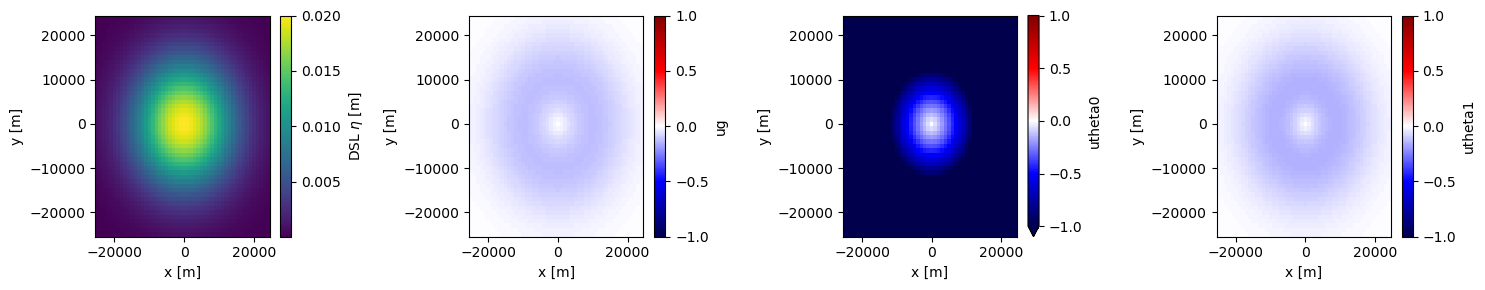

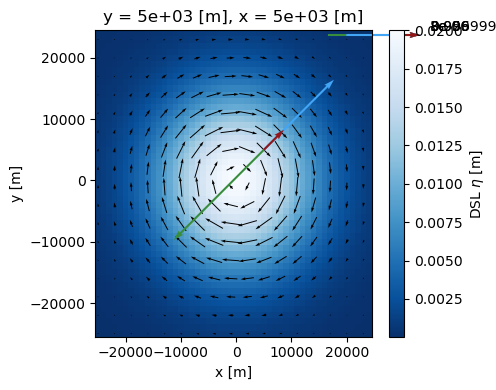

In [400]:
ds = create_champ(L=25e3, dsl_amp=2e-2)

kwargs = {'vmin':-1, 'vmax':1, 'cmap':'seismic'}
fig, axs = plt.subplots(1,4, frameon=False, figsize=(15, 3))
ds.eta.plot(ax=axs[0])
ds.ug.plot(ax=axs[1], **kwargs)
ds.utheta0.plot(ax=axs[2], **kwargs)
ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()


fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=axs, cmap='Blues_r')
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
kwargs={'pivot':'tail', 'scale':3e-5}

a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=axs, color=c0['cor'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=axs, color=c0['ggd'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=axs, color=c0['acc'], **kwargs)


fig.tight_layout()

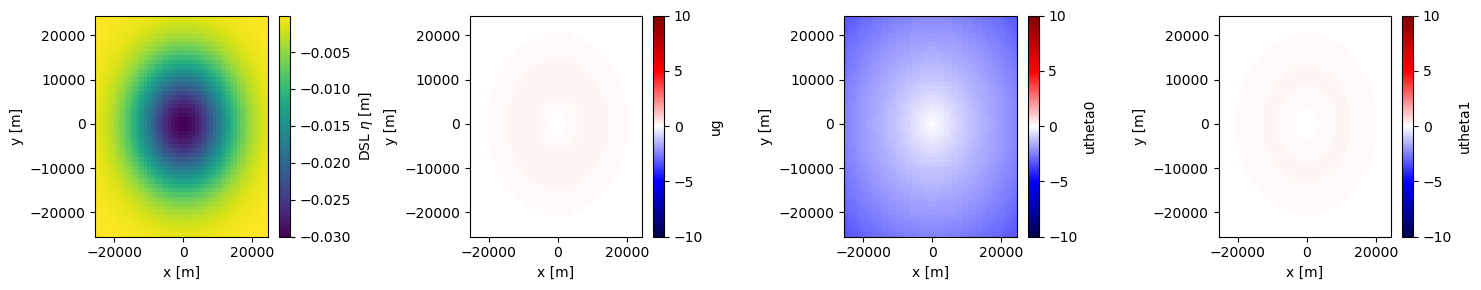

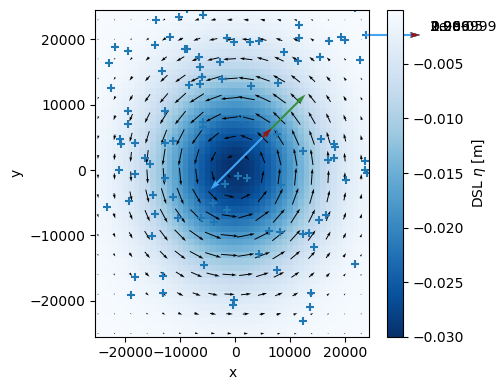

In [425]:
ds = create_champ(L=25e3, dsl_amp=-3e-2)

kwargs = {'vmin':-10, 'vmax':10, 'cmap':'seismic'}
fig, axs = plt.subplots(1,4, frameon=False, figsize=(15, 3))
ds.eta.plot(ax=axs[0])
ds.ug.plot(ax=axs[1], **kwargs)
ds.utheta0.plot(ax=axs[2], **kwargs)
ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()


fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=axs, cmap='Blues_r')
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
kwargs={'pivot':'tail', 'scale':6e-5}
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=axs, color=c0['cor'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=axs, color=c0['ggd'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=axs, color=c0['acc'], **kwargs)
axs.set_title('')

dsa.plot.scatter(x='x', y='y', marker = '+')

fig.tight_layout()

## Coloc files

In [451]:
L=25e3
xa = np.random.uniform(-1, 1,10000)*L
ya = np.random.uniform(-1, 1,10000)*L
dsa = ds.interp(x=('row_number', xa), y=('row_number', ya))

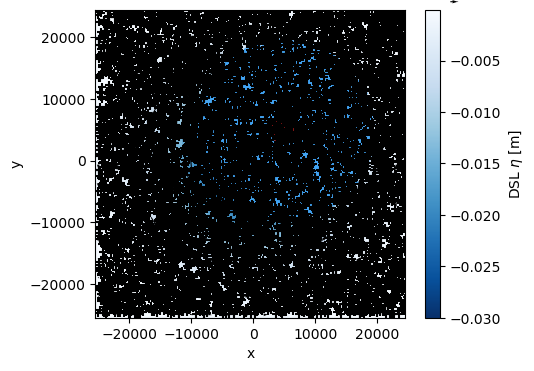

In [452]:
fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=axs, cmap='Blues_r')
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
kwargs={'pivot':'tail', 'scale':6e-5}
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=axs, color=c0['cor'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=axs, color=c0['ggd'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=axs, color=c0['acc'], **kwargs)
axs.set_title('')

dsa.plot.scatter(x='x', y='y', marker = '+', color='k')

In [453]:
dsa['wdx'] = dsa['acc']/dsa['acc']-1
dsa['wdy'] = dsa['acc']/dsa['acc']-1

In [454]:
from diagnosis import create_prod_exc_sum

In [ ]:
dfa =dsa.to_dataframe()

In [ ]:
def create_prod_exc_sum(df, null_mean = False):
    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}

            if null_mean : 
                for v in l:
                    df[l[v]] = df[l[v]] - df[l[v]].mean()
                
            # sum 
            ds['sum'+direction] = sum([df[l[v]] for v in l])

            # simple var + sum- one term
            for v in l :
                ds[l[v]] = df[l[v]]
                ds['exc'+direction+'_'+v] = ds['sum'+direction]-ds[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                ds['prod'+direction+'_'+'_'.join(c)] = ds[c[0]+direction] * ds[c[1]+direction]
    return ds

In [ ]:
dsa_ = create_prod_exc_sum(dfa, null_mean = False)

In [ ]:
dsa_

In [ ]:
from diagnosis import compute_mean_square
dsm = compute_mean_square(dsa_, dirname = ('x', 'y'))

In [ ]:
dsm